# Unified notebook — Baseline + FinBERT variants + comparison

This notebook merges the 4 variants into one pipeline:

1. **Baseline TF-IDF + Logistic Regression**
2. **01 FinBERT classifier**
3. **02 FinBERT + BiLSTM**
4. **03 FinBERT + BiLSTM + Attention**
5. **Unified comparison block**

Main changes already integrated:

- unified JSON schema for all models
- saved test predictions + labels for all models
- comparison notebook no longer needs to reload PyTorch checkpoints
- runtime-reduction defaults adapted to a **CPU-only laptop**
- one clean block per model

You can run the notebook sequentially from top to bottom.

In [1]:
# =========================
# 0) Imports & global setup
# =========================
import os
import gc
import json
import time
import random
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# Paths
ROOT = Path(".")
DATA_DIR = ROOT / "data" / "processed"
if not DATA_DIR.exists():
    DATA_DIR = Path(".")  # fallback if csv files are next to notebook

RES_DIR = ROOT / "results"
RES_DIR.mkdir(parents=True, exist_ok=True)

MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

LABEL_TO_NAME = {0: "négatif", 1: "neutre", 2: "positif"}
LABEL_NAMES = [LABEL_TO_NAME[i] for i in [0, 1, 2]]

BACKBONE = "ProsusAI/finbert"
SPECIAL_TOKENS = [f"TICKER_{s}" for s in [
    "AAPL","MSFT","GOOGL","AMZN","TSLA","META","NVDA","BRK","JPM",
    "JNJ","V","PG","UNH","HD","MA","PYPL","BAC","DIS","ADBE","NFLX",
    "CMCSA","XOM","VZ","INTC","T","CSCO","PFE"
]] + ["AMOUNT_"]

d:\M2_MoSEF\NLP_Project\NLP_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE: cpu


In [2]:
# =========================
# 1) Load the split files
# =========================
train_path = DATA_DIR / "train.csv"
val_path   = DATA_DIR / "val.csv"
test_path  = DATA_DIR / "test.csv"

if not train_path.exists():
    train_path = Path("train.csv")
    val_path   = Path("val.csv")
    test_path  = Path("test.csv")

df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

TEXT_COL_CANDIDATES = ["Tweet_clean", "text", "tweet", "Tweet_original"]
LABEL_COL_CANDIDATES = ["label", "sentiment_label"]

TEXT_COL = next((c for c in TEXT_COL_CANDIDATES if c in df_train.columns), None)
LABEL_COL = next((c for c in LABEL_COL_CANDIDATES if c in df_train.columns), None)

if TEXT_COL is None:
    raise ValueError(f"Text column not found. Available columns: {list(df_train.columns)}")
if LABEL_COL is None:
    raise ValueError(f"Label column not found. Available columns: {list(df_train.columns)}")

print("TEXT_COL :", TEXT_COL)
print("LABEL_COL:", LABEL_COL)
print("Train:", df_train.shape, "| Val:", df_val.shape, "| Test:", df_test.shape)

X_train = df_train[TEXT_COL].astype(str).fillna("")
X_val   = df_val[TEXT_COL].astype(str).fillna("")
X_test  = df_test[TEXT_COL].astype(str).fillna("")

y_train = df_train[LABEL_COL].astype(int).to_numpy()
y_val   = df_val[LABEL_COL].astype(int).to_numpy()
y_test  = df_test[LABEL_COL].astype(int).to_numpy()

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=y_train
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights)

TEXT_COL : Tweet_clean
LABEL_COL: label
Train: (29576, 5) | Val: (6338, 5) | Test: (6338, 5)
Class weights: [1.76488841 0.7626415  0.89113863]


In [17]:
# =========================
# 2) Common helper functions
# =========================
class EncodedTweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": self.labels[idx]
        }


def get_tokenizer(backbone=BACKBONE):
    tokenizer = AutoTokenizer.from_pretrained(backbone)
    tokenizer.add_tokens(SPECIAL_TOKENS)
    return tokenizer


def build_encoded_loaders(
    tokenizer,
    x_train, y_train,
    x_val, y_val,
    x_test, y_test,
    max_length=96,
    batch_size=16,
    num_workers=0
):
    train_enc = tokenizer(
        list(x_train),
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors="pt"
    )
    val_enc = tokenizer(
        list(x_val),
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors="pt"
    )
    test_enc = tokenizer(
        list(x_test),
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors="pt"
    )

    train_ds = EncodedTweetDataset(train_enc, y_train)
    val_ds   = EncodedTweetDataset(val_enc, y_val)
    test_ds  = EncodedTweetDataset(test_enc, y_test)

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=pin_memory)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

    return train_loader, val_loader, test_loader


def evaluate_sklearn(model, X, y_true):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro")),
        "f1_per_class": {
            "negatif": float(f1_score(y_true, y_pred, average=None)[0]),
            "neutre": float(f1_score(y_true, y_pred, average=None)[1]),
            "positif": float(f1_score(y_true, y_pred, average=None)[2]),
        },
        "roc_auc": float(roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro"))
    }
    return metrics, y_pred, y_prob


def evaluate_torch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            total_loss += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    metrics = {
        "loss": float(total_loss / len(loader)),
        "accuracy": float(accuracy_score(all_labels, all_preds)),
        "f1_macro": float(f1_score(all_labels, all_preds, average="macro")),
        "f1_per_class": {
            "negatif": float(f1_score(all_labels, all_preds, average=None)[0]),
            "neutre": float(f1_score(all_labels, all_preds, average=None)[1]),
            "positif": float(f1_score(all_labels, all_preds, average=None)[2]),
        },
        "roc_auc": float(roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro"))
    }
    return metrics, all_preds, all_labels, all_probs


import json
from pathlib import Path
import numpy as np

import json
from pathlib import Path
import numpy as np

def to_jsonable(obj):
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

def normalize_f1_per_class(f1pc):
    if isinstance(f1pc, dict):
        return {
            "negatif": round(float(f1pc["negatif"]), 4),
            "neutre": round(float(f1pc["neutre"]), 4),
            "positif": round(float(f1pc["positif"]), 4),
        }

    return {
        "negatif": round(float(f1pc[0]), 4),
        "neutre": round(float(f1pc[1]), 4),
        "positif": round(float(f1pc[2]), 4),
    }

def save_unified_metrics(
    out_json_path,
    model_name,
    val_metrics,
    test_metrics,
    training_time_minutes,
    best_epoch,
    trainable_params,
    val_f1_history,
    config
):
    payload = {
        "model": model_name,
        "val": {
            "loss": round(float(val_metrics["loss"]), 4),
            "accuracy": round(float(val_metrics["accuracy"]), 4),
            "f1_macro": round(float(val_metrics["f1_macro"]), 4),
            "f1_per_class": normalize_f1_per_class(val_metrics["f1_per_class"]),
            "roc_auc": round(float(val_metrics["roc_auc"]), 4),
        },
        "test": {
            "loss": round(float(test_metrics["loss"]), 4),
            "accuracy": round(float(test_metrics["accuracy"]), 4),
            "f1_macro": round(float(test_metrics["f1_macro"]), 4),
            "f1_per_class": normalize_f1_per_class(test_metrics["f1_per_class"]),
            "roc_auc": round(float(test_metrics["roc_auc"]), 4),
        },
        "training_time_minutes": round(float(training_time_minutes), 1),
        "best_epoch": int(best_epoch),
        "trainable_params": int(trainable_params),
        "val_f1_history": [round(float(v), 4) for v in val_f1_history],
        "config": to_jsonable(config),
    }

    with open(out_json_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)

    return payload


def plot_confusion(y_true, y_pred, title, save_path=None, normalize=False, cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred, normalize="true" if normalize else None)
    plt.figure(figsize=(6, 5))
    fmt = ".2%" if normalize else "d"
    sns.heatmap(
        cm, annot=True, fmt=fmt, cmap=cmap,
        xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES
    )
    plt.title(title)
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=140, bbox_inches="tight")
    plt.show()


def free_memory(*objs):
    for obj in objs:
        try:
            del obj
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## Runtime note

The default deep-learning configs below are already reduced for a CPU laptop:

- **Model 01:** lower `MAX_LENGTH`, early stopping, partial freezing
- **Model 02:** lower `MAX_LENGTH`, more frozen BERT layers, smaller BiLSTM
- **Model 03:** lower `MAX_LENGTH`, more frozen BERT layers, smaller BiLSTM, fewer epochs

You can tighten them even more if runtime is still too high.

{
  "model": "baseline_tfidf_logreg",
  "val": {
    "loss": 0.7123,
    "accuracy": 0.6912,
    "f1_macro": 0.6731,
    "f1_per_class": {
      "negatif": 0.6019,
      "neutre": 0.7123,
      "positif": 0.7052
    },
    "roc_auc": 0.8523
  },
  "test": {
    "loss": 0.7057,
    "accuracy": 0.6939,
    "f1_macro": 0.6752,
    "f1_per_class": {
      "negatif": 0.6015,
      "neutre": 0.7163,
      "positif": 0.7078
    },
    "roc_auc": 0.8557
  },
  "training_time_minutes": 0.8,
  "best_epoch": 1,
  "trainable_params": 29685,
  "val_f1_history": [
    0.6731
  ],
  "config": {
    "vectorizer": "tfidf",
    "classifier": "logistic_regression",
    "max_length": null,
    "batch_size": null,
    "seed": 42
  }
}
              precision    recall  f1-score   support

     négatif       0.69      0.53      0.60      1197
      neutre       0.69      0.75      0.72      2771
     positif       0.70      0.71      0.71      2370

    accuracy                           0.69      6338
   m

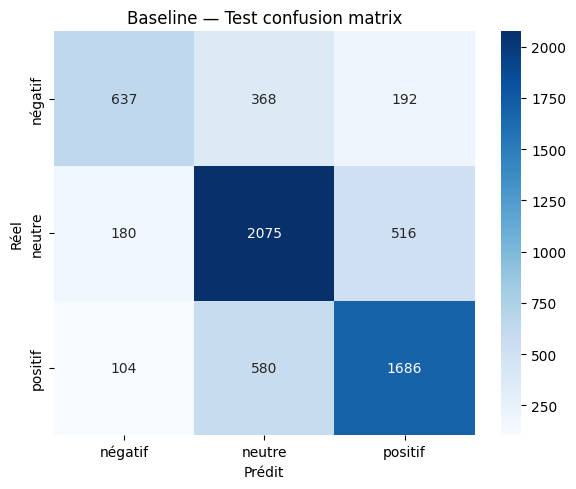

In [37]:
import json
import time
import joblib
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    log_loss,
    classification_report
)

# ============================================
# 3) Baseline block — TF-IDF + LogisticRegression
# ============================================
BASELINE_MODEL_NAME = "baseline_tfidf_logreg"

def evaluate_sklearn(model, X, y):
    preds = model.predict(X)
    probs = model.predict_proba(X)

    metrics = {
        "loss": log_loss(y, probs, labels=np.unique(y)),
        "accuracy": accuracy_score(y, preds),
        "f1_macro": f1_score(y, preds, average="macro"),
        "f1_per_class": f1_score(y, preds, average=None),
        "roc_auc": roc_auc_score(y, probs, multi_class="ovr")
    }
    return metrics, preds, probs

baseline_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 1),
        min_df=5,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        max_iter=300,
        n_jobs=-1,
        random_state=SEED
    ))
])

t0 = time.time()
baseline_pipeline.fit(X_train, y_train)
baseline_training_minutes = (time.time() - t0) / 60

baseline_val_metrics, baseline_val_preds, baseline_val_probs = evaluate_sklearn(
    baseline_pipeline, X_val, y_val
)
baseline_test_metrics, baseline_test_preds, baseline_test_probs = evaluate_sklearn(
    baseline_pipeline, X_test, y_test
)

# logistic regression trainable params
baseline_clf = baseline_pipeline.named_steps["clf"]
baseline_trainable_params = baseline_clf.coef_.size + baseline_clf.intercept_.size

joblib.dump(baseline_pipeline, MODELS_DIR / "baseline_tfidf_logreg.joblib")
np.save(RES_DIR / "baseline_test_preds.npy", np.array(baseline_test_preds))
np.save(RES_DIR / "baseline_test_labels.npy", np.array(y_test))

metrics_baseline = save_unified_metrics(
    out_json_path=RES_DIR / "metrics_baseline.json",
    model_name=BASELINE_MODEL_NAME,
    val_metrics=baseline_val_metrics,      # keep real loss
    test_metrics=baseline_test_metrics,    # keep real loss
    training_time_minutes=baseline_training_minutes,
    best_epoch=1,
    trainable_params=baseline_trainable_params,
    val_f1_history=[baseline_val_metrics["f1_macro"]],
    config={
        "vectorizer": "tfidf",
        "classifier": "logistic_regression",
        "max_length": None,
        "batch_size": None,
        "seed": SEED
    },
)

print(json.dumps(metrics_baseline, indent=2, ensure_ascii=False))
print(classification_report(y_test, baseline_test_preds, target_names=LABEL_NAMES))
plot_confusion(
    y_test,
    baseline_test_preds,
    "Baseline — Test confusion matrix",
    RES_DIR / "confusion_baseline_test.png"
)

## 01) FinBERT classifier block

This block uses a lighter configuration than your original notebook:

- `MAX_LENGTH = 96` instead of 128
- freeze embeddings + first 8 BERT layers
- `MAX_EPOCHS = 5`
- `PATIENCE = 2`

That usually saves a lot of CPU time while keeping the comparison meaningful.

In [9]:
# ============================================
# 4) Model 01 block — FinBERT classifier
# ============================================
CFG_01 = {
    "model_name": "01_finbert_classifier",
    "model_dir": MODELS_DIR / "fintwit_classifier",
    "max_length": 32,
    "batch_size": 16,
    "lr_bert": 2e-5,
    "lr_head": 1e-3,
    "weight_decay": 0.01,
    "max_epochs": 4,
    "patience": 1,
    "warmup_ratio": 0.10,
    "freeze_layers": 10,
    "seed": SEED,
}
CFG_01["model_dir"].mkdir(parents=True, exist_ok=True)

tokenizer_01 = get_tokenizer(BACKBONE)
train_loader_01, val_loader_01, test_loader_01 = build_encoded_loaders(
    tokenizer_01, X_train, y_train, X_val, y_val, X_test, y_test,
    max_length=CFG_01["max_length"],
    batch_size=CFG_01["batch_size"]
)

class FinBertClassifier(nn.Module):
    def __init__(self, backbone_name, num_classes=3, dropout1=0.3, dropout2=0.2, freeze_layers=8, tokenizer_len=None):
        super().__init__()
        self.bert = AutoModel.from_pretrained(backbone_name)
        if tokenizer_len is not None:
            self.bert.resize_token_embeddings(tokenizer_len)

        # freeze embeddings + first n layers
        for p in self.bert.embeddings.parameters():
            p.requires_grad = False
        for layer in self.bert.encoder.layer[:freeze_layers]:
            for p in layer.parameters():
                p.requires_grad = False

        hidden_size = self.bert.config.hidden_size
        self.drop1 = nn.Dropout(dropout1)
        self.dense = nn.Linear(hidden_size, 256)
        self.relu = nn.ReLU()
        self.drop2 = nn.Dropout(dropout2)
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        x = self.drop1(cls_output)
        x = self.relu(self.dense(x))
        x = self.drop2(x)
        logits = self.classifier(x)
        return logits


def train_epoch_01(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0.0

    for step, batch in enumerate(loader, start=1):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

        if step % 100 == 0 or step == len(loader):
            print(f"    batch {step}/{len(loader)} | avg_loss={total_loss/step:.4f}")

    return total_loss / len(loader)


model_01 = FinBertClassifier(
    BACKBONE,
    freeze_layers=CFG_01["freeze_layers"],
    tokenizer_len=len(tokenizer_01)
).to(DEVICE)

trainable_params_01 = sum(p.numel() for p in model_01.parameters() if p.requires_grad)
print("Trainable params (01):", f"{trainable_params_01:,}")

bert_params_01 = [p for p in model_01.bert.parameters() if p.requires_grad]
head_params_01 = list(model_01.dense.parameters()) + list(model_01.classifier.parameters())

optimizer_01 = torch.optim.AdamW([
    {"params": bert_params_01, "lr": CFG_01["lr_bert"]},
    {"params": head_params_01, "lr": CFG_01["lr_head"]},
], weight_decay=CFG_01["weight_decay"])

total_steps_01 = len(train_loader_01) * CFG_01["max_epochs"]
warmup_steps_01 = int(total_steps_01 * CFG_01["warmup_ratio"])
scheduler_01 = get_linear_schedule_with_warmup(
    optimizer_01,
    num_warmup_steps=warmup_steps_01,
    num_training_steps=total_steps_01
)
criterion_01 = nn.CrossEntropyLoss(weight=class_weights_tensor.to(DEVICE))

history_01 = {"train_loss": [], "val_loss": [], "val_f1": [], "val_acc": []}
best_val_f1_01 = -1.0
best_epoch_01 = 0
patience_counter_01 = 0

t0 = time.time()
for epoch in range(1, CFG_01["max_epochs"] + 1):
    epoch_t0 = time.time()

    train_loss = train_epoch_01(model_01, train_loader_01, optimizer_01, scheduler_01, criterion_01)
    val_metrics_epoch, _, _, _ = evaluate_torch(model_01, val_loader_01, criterion_01)

    history_01["train_loss"].append(train_loss)
    history_01["val_loss"].append(val_metrics_epoch["loss"])
    history_01["val_f1"].append(val_metrics_epoch["f1_macro"])
    history_01["val_acc"].append(val_metrics_epoch["accuracy"])

    print(
        f"[01] Epoch {epoch:02d}/{CFG_01['max_epochs']} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics_epoch['loss']:.4f} | "
        f"val_acc={val_metrics_epoch['accuracy']:.4f} | "
        f"val_f1={val_metrics_epoch['f1_macro']:.4f} | "
        f"time={(time.time()-epoch_t0)/60:.1f} min"
    )

    if val_metrics_epoch["f1_macro"] > best_val_f1_01:
        best_val_f1_01 = val_metrics_epoch["f1_macro"]
        best_epoch_01 = epoch
        patience_counter_01 = 0
        torch.save(model_01.state_dict(), CFG_01["model_dir"] / "best_model.pt")
    else:
        patience_counter_01 += 1
        if patience_counter_01 >= CFG_01["patience"]:
            print(f"[01] Early stopping at epoch {epoch}")
            break

training_minutes_01 = (time.time() - t0) / 60

model_01.load_state_dict(torch.load(CFG_01["model_dir"] / "best_model.pt", map_location=DEVICE))
val_metrics_01, val_preds_01, val_labels_01, val_probs_01 = evaluate_torch(model_01, val_loader_01, criterion_01)
test_metrics_01, test_preds_01, test_labels_01, test_probs_01 = evaluate_torch(model_01, test_loader_01, criterion_01)

np.save(RES_DIR / "01_test_preds.npy", np.array(test_preds_01))
np.save(RES_DIR / "01_test_labels.npy", np.array(test_labels_01))

metrics_01 = save_unified_metrics(
    out_json_path=RES_DIR / "metrics_01.json",
    model_name=CFG_01["model_name"],
    val_metrics=val_metrics_01,
    test_metrics=test_metrics_01,
    training_time_minutes=training_minutes_01,
    best_epoch=best_epoch_01,
    trainable_params=trainable_params_01,
    val_f1_history=history_01["val_f1"],
    config=CFG_01
)

print(json.dumps(metrics_01, indent=2, ensure_ascii=False))
print(classification_report(test_labels_01, test_preds_01, target_names=LABEL_NAMES))
plot_confusion(test_labels_01, test_preds_01, "01 FinBERT classifier — Test confusion matrix", RES_DIR / "confusion_01_test.png")

free_memory(model_01, optimizer_01, scheduler_01, train_loader_01, val_loader_01, test_loader_01)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 32774.43it/s]
BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable params (01): 14,963,971
    batch 100/1849 | avg_loss=1.0211
    batch 200/1849 | avg_loss=0.9789
    batch 300/1849 | avg_loss=0.9517
    batch 400/1849 | avg_loss=0.9276
    batch 500/1849 | avg_loss=0.9191
    batch 600/1849 | avg_loss=0.9122
    batch 700/1849 | avg_loss=0.9017
    batch 800/1849 | avg_loss=0.8919
    batch 900/1849 | avg_loss=0.8844
    batch 1000/1849 | avg_loss=0.8812
    batch 1100/1849 | avg_loss=0.8745
    batch 1200/1849 | avg_loss=0.8706
    batch 1300/1849 | avg_loss=0.8646
    batch 1400/1849 | avg_loss=0.8592
    batch 1500/1849 | avg_loss=0.8562
    batch 1600/1849 | avg_loss=0.8519
    batch 1700/1849 | avg_loss=0.8470
    batch 1800/1849 | avg_loss=0.8446
    batch 1849/1849 | avg_loss=0.8431
[01] Epoch 01/4 | train_loss=0.8431 | val_loss=0.7752 | val_acc=0.6516 | val_f1=0.6471 | time=37.9 min
    batch 100/1849 | avg_loss=0.7807
    batch 200/1849 | avg_loss=0.7669
    batch 300/1849 | avg_loss=0.7576
    batch 400/1849 | avg_loss=0.7554
  

TypeError: Object of type WindowsPath is not JSON serializable

{
  "model": "01_finbert_classifier",
  "val": {
    "loss": 0.7032,
    "accuracy": 0.6901,
    "f1_macro": 0.6837,
    "f1_per_class": {
      "negatif": 0.6454,
      "neutre": 0.6918,
      "positif": 0.7139
    },
    "roc_auc": 0.8618
  },
  "test": {
    "loss": 0.718,
    "accuracy": 0.6904,
    "f1_macro": 0.6848,
    "f1_per_class": {
      "negatif": 0.6517,
      "neutre": 0.6899,
      "positif": 0.7128
    },
    "roc_auc": 0.8607
  },
  "training_time_minutes": 151.5,
  "best_epoch": 3,
  "trainable_params": 14963971,
  "val_f1_history": [
    0.6471,
    0.6624,
    0.6837,
    0.6821
  ],
  "config": {
    "model_name": "01_finbert_classifier",
    "model_dir": "models\\fintwit_classifier",
    "max_length": 32,
    "batch_size": 16,
    "lr_bert": 2e-05,
    "lr_head": 0.001,
    "weight_decay": 0.01,
    "max_epochs": 4,
    "patience": 1,
    "warmup_ratio": 0.1,
    "freeze_layers": 10,
    "seed": 42
  }
}
              precision    recall  f1-score   support

   

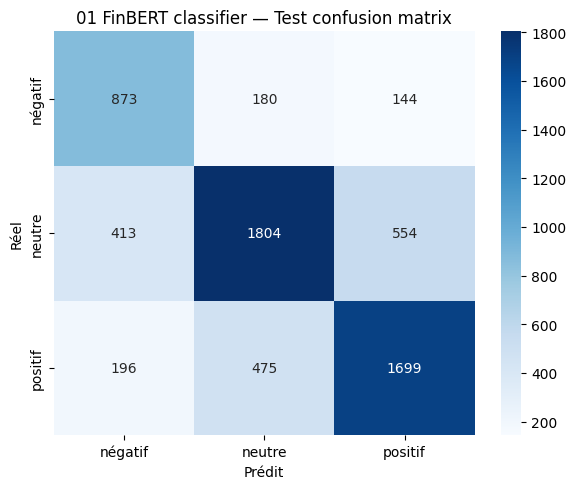

In [ ]:
model_01.load_state_dict(torch.load(CFG_01["model_dir"] / "best_model.pt", map_location=DEVICE))
val_metrics_01, val_preds_01, val_labels_01, val_probs_01 = evaluate_torch(model_01, val_loader_01, criterion_01)
test_metrics_01, test_preds_01, test_labels_01, test_probs_01 = evaluate_torch(model_01, test_loader_01, criterion_01)

np.save(RES_DIR / "01_test_preds.npy", np.array(test_preds_01))
np.save(RES_DIR / "01_test_labels.npy", np.array(test_labels_01))

metrics_01 = save_unified_metrics(
    out_json_path=RES_DIR / "metrics_01.json",
    model_name=CFG_01["model_name"],
    val_metrics=val_metrics_01,
    test_metrics=test_metrics_01,
    training_time_minutes=training_minutes_01,
    best_epoch=best_epoch_01,
    trainable_params=trainable_params_01,
    val_f1_history=history_01["val_f1"],
    config=CFG_01
)

print(json.dumps(metrics_01, indent=2, ensure_ascii=False))
print(classification_report(test_labels_01, test_preds_01, target_names=LABEL_NAMES))
plot_confusion(test_labels_01, test_preds_01, "01 FinBERT classifier — Test confusion matrix", RES_DIR / "confusion_01_test.png")

In [16]:
print(type(val_metrics_01["f1_per_class"]))
print(val_metrics_01["f1_per_class"])
print(type(test_metrics_01["f1_per_class"]))
print(test_metrics_01["f1_per_class"])

<class 'dict'>
{'negatif': 0.6454445664105378, 'neutre': 0.6918165989553106, 'positif': 0.7138667783829075}
<class 'dict'>
{'negatif': 0.6517357222844344, 'neutre': 0.6898661567877629, 'positif': 0.7128172855045102}


## 02) FinBERT + BiLSTM block

Integrated speed reductions:

- `MAX_LENGTH = 80`
- `FREEZE_LAYERS = 10`
- `lstm_hidden = 128` instead of 256
- `MAX_EPOCHS = 6`
- `PATIENCE = 2`

This is much more realistic for your CPU machine.

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 67046.87it/s]
BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable params (02): 8,368,643
    batch 200/1849 | avg_loss=1.0170 | elapsed=3.4 min
    batch 400/1849 | avg_loss=0.9464 | elapsed=6.9 min
    batch 600/1849 | avg_loss=0.9059 | elapsed=10.3 min
    batch 800/1849 | avg_loss=0.8809 | elapsed=13.8 min
    batch 1000/1849 | avg_loss=0.8679 | elapsed=17.2 min
    batch 1200/1849 | avg_loss=0.8566 | elapsed=20.6 min
    batch 1400/1849 | avg_loss=0.8459 | elapsed=24.1 min
    batch 1600/1849 | avg_loss=0.8400 | elapsed=27.5 min
    batch 1800/1849 | avg_loss=0.8338 | elapsed=31.0 min
[02] Epoch 01/4 | train_loss=0.8325 | val_loss=0.7317 | val_acc=0.6448 | val_f1=0.6398 | time=35.5 min
    batch 200/1849 | avg_loss=0.7371 | elapsed=3.4 min
    batch 400/1849 | avg_loss=0.7362 | elapsed=6.9 min
    batch 600/1849 | avg_loss=0.7413 | elapsed=10.4 min
    batch 800/1849 | avg_loss=0.7369 | elapsed=13.8 min
    batch 1000/1849 | avg_loss=0.7354 | elapsed=17.3 min
    batch 1200/1849 | avg_loss=0.7282 | elapsed=20.9 min
    batch 1400/1849 |

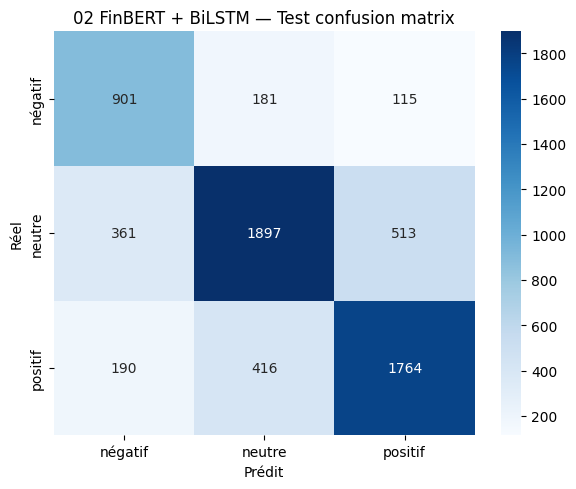

In [ ]:
import math
# ============================================
# 5) Model 02 block — FinBERT + BiLSTM
# ============================================
CFG_02 = {
    "model_name": "02_finbert_bilstm",
    "model_dir": MODELS_DIR / "fintwit_bilstm",
    "max_length": 48,
    "batch_size": 16,
    "grad_accum": 1,
    "lstm_hidden": 96,
    "lr_bert": 2e-5,
    "lr_head": 1e-3,
    "weight_decay": 0.01,
    "max_epochs": 4,
    "patience": 1,
    "warmup_ratio": 0.10,
    "freeze_layers": 11,
    "seed": SEED,
}
CFG_02["model_dir"].mkdir(parents=True, exist_ok=True)

tokenizer_02 = get_tokenizer(BACKBONE)
train_loader_02, val_loader_02, test_loader_02 = build_encoded_loaders(
    tokenizer_02, X_train, y_train, X_val, y_val, X_test, y_test,
    max_length=CFG_02["max_length"],
    batch_size=CFG_02["batch_size"]
)

class FinBertBiLSTM(nn.Module):
    def __init__(self, backbone_name, num_classes=3, lstm_hidden=128, freeze_layers=10, tokenizer_len=None):
        super().__init__()
        self.bert = AutoModel.from_pretrained(backbone_name)
        if tokenizer_len is not None:
            self.bert.resize_token_embeddings(tokenizer_len)

        for p in self.bert.embeddings.parameters():
            p.requires_grad = False
        for i, layer in enumerate(self.bert.encoder.layer):
            if i < freeze_layers:
                for p in layer.parameters():
                    p.requires_grad = False

        hidden_size = self.bert.config.hidden_size
        self.bilstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.drop1 = nn.Dropout(0.3)
        self.dense = nn.Linear(lstm_hidden * 2, 128)
        self.relu = nn.ReLU()
        self.drop2 = nn.Dropout(0.2)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        seq = outputs.last_hidden_state
        _, (h_n, _) = self.bilstm(seq)
        h_forward = h_n[-2]
        h_backward = h_n[-1]
        x = torch.cat([h_forward, h_backward], dim=1)
        x = self.drop1(x)
        x = self.relu(self.dense(x))
        x = self.drop2(x)
        logits = self.classifier(x)
        return logits


def train_epoch_02(model, loader, optimizer, scheduler, criterion, grad_accum=1, log_every=200):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()
    t0 = time.time()

    for step, batch in enumerate(loader):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels) / grad_accum
        loss.backward()

        total_loss += loss.item() * grad_accum

        if (step + 1) % grad_accum == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        if (step + 1) % log_every == 0:
            elapsed_min = (time.time() - t0) / 60
            avg_loss = total_loss / (step + 1)
            print(f"    batch {step+1}/{len(loader)} | avg_loss={avg_loss:.4f} | elapsed={elapsed_min:.1f} min")

    if len(loader) % grad_accum != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    return total_loss / len(loader)


model_02 = FinBertBiLSTM(
    BACKBONE,
    lstm_hidden=CFG_02["lstm_hidden"],
    freeze_layers=CFG_02["freeze_layers"],
    tokenizer_len=len(tokenizer_02)
).to(DEVICE)

trainable_params_02 = sum(p.numel() for p in model_02.parameters() if p.requires_grad)
print("Trainable params (02):", f"{trainable_params_02:,}")

bert_params_02 = [p for p in model_02.bert.parameters() if p.requires_grad]
head_params_02 = (
    list(model_02.bilstm.parameters()) +
    list(model_02.dense.parameters()) +
    list(model_02.classifier.parameters())
)

optimizer_02 = torch.optim.AdamW([
    {"params": bert_params_02, "lr": CFG_02["lr_bert"]},
    {"params": head_params_02, "lr": CFG_02["lr_head"]},
], weight_decay=CFG_02["weight_decay"])

effective_steps_02 = math.ceil(len(train_loader_02) / CFG_02["grad_accum"]) * CFG_02["max_epochs"]
warmup_steps_02 = int(effective_steps_02 * CFG_02["warmup_ratio"])
scheduler_02 = get_linear_schedule_with_warmup(
    optimizer_02,
    num_warmup_steps=warmup_steps_02,
    num_training_steps=effective_steps_02
)
criterion_02 = nn.CrossEntropyLoss(weight=class_weights_tensor.to(DEVICE))

history_02 = {"train_loss": [], "val_loss": [], "val_f1": [], "val_acc": []}
best_val_f1_02 = -1.0
best_epoch_02 = 0
patience_counter_02 = 0

t0 = time.time()
for epoch in range(1, CFG_02["max_epochs"] + 1):
    epoch_t0 = time.time()

    train_loss = train_epoch_02(
        model_02, train_loader_02, optimizer_02, scheduler_02, criterion_02,
        grad_accum=CFG_02["grad_accum"]
    )
    val_metrics_epoch, _, _, _ = evaluate_torch(model_02, val_loader_02, criterion_02)

    history_02["train_loss"].append(train_loss)
    history_02["val_loss"].append(val_metrics_epoch["loss"])
    history_02["val_f1"].append(val_metrics_epoch["f1_macro"])
    history_02["val_acc"].append(val_metrics_epoch["accuracy"])

    print(
        f"[02] Epoch {epoch:02d}/{CFG_02['max_epochs']} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics_epoch['loss']:.4f} | "
        f"val_acc={val_metrics_epoch['accuracy']:.4f} | "
        f"val_f1={val_metrics_epoch['f1_macro']:.4f} | "
        f"time={(time.time()-epoch_t0)/60:.1f} min"
    )

    if val_metrics_epoch["f1_macro"] > best_val_f1_02:
        best_val_f1_02 = val_metrics_epoch["f1_macro"]
        best_epoch_02 = epoch
        patience_counter_02 = 0
        torch.save(model_02.state_dict(), CFG_02["model_dir"] / "best_model.pt")
    else:
        patience_counter_02 += 1
        if patience_counter_02 >= CFG_02["patience"]:
            print(f"[02] Early stopping at epoch {epoch}")
            break

training_minutes_02 = (time.time() - t0) / 60

model_02.load_state_dict(torch.load(CFG_02["model_dir"] / "best_model.pt", map_location=DEVICE))
val_metrics_02, val_preds_02, val_labels_02, val_probs_02 = evaluate_torch(model_02, val_loader_02, criterion_02)
test_metrics_02, test_preds_02, test_labels_02, test_probs_02 = evaluate_torch(model_02, test_loader_02, criterion_02)

np.save(RES_DIR / "02_test_preds.npy", np.array(test_preds_02))
np.save(RES_DIR / "02_test_labels.npy", np.array(test_labels_02))

metrics_02 = save_unified_metrics(
    out_json_path=RES_DIR / "metrics_02.json",
    model_name=CFG_02["model_name"],
    val_metrics=val_metrics_02,
    test_metrics=test_metrics_02,
    training_time_minutes=training_minutes_02,
    best_epoch=best_epoch_02,
    trainable_params=trainable_params_02,
    val_f1_history=history_02["val_f1"],
    config=CFG_02
)

print(json.dumps(metrics_02, indent=2, ensure_ascii=False))
print(classification_report(test_labels_02, test_preds_02, target_names=LABEL_NAMES))
plot_confusion(test_labels_02, test_preds_02, "02 FinBERT + BiLSTM — Test confusion matrix", RES_DIR / "confusion_02_test.png")

free_memory(model_02, optimizer_02, scheduler_02, train_loader_02, val_loader_02, test_loader_02)

## 03) FinBERT + BiLSTM + Attention block

Integrated speed reductions:

- `MAX_LENGTH = 64`
- `FREEZE_LAYERS = 10`
- `lstm_hidden = 128`
- `MAX_EPOCHS = 5`
- `PATIENCE = 2`

This is the most compute-expensive variant, so the defaults are stricter.

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11112.29it/s]
BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable params (03): 8,122,500
    batch 200/1849 | avg_loss=1.0463 | elapsed=3.5 min | est_epoch=32.0 min
    batch 400/1849 | avg_loss=0.9725 | elapsed=6.9 min | est_epoch=32.0 min
    batch 600/1849 | avg_loss=0.9457 | elapsed=10.4 min | est_epoch=32.1 min
    batch 800/1849 | avg_loss=0.9260 | elapsed=13.9 min | est_epoch=32.1 min
    batch 1000/1849 | avg_loss=0.9030 | elapsed=17.4 min | est_epoch=32.2 min
    batch 1200/1849 | avg_loss=0.8856 | elapsed=20.9 min | est_epoch=32.2 min
    batch 1400/1849 | avg_loss=0.8726 | elapsed=24.3 min | est_epoch=32.1 min
    batch 1600/1849 | avg_loss=0.8666 | elapsed=27.7 min | est_epoch=32.0 min
    batch 1800/1849 | avg_loss=0.8569 | elapsed=31.1 min | est_epoch=31.9 min
[03] Epoch 01/4 | train_loss=0.8547 | val_loss=0.7703 | val_acc=0.6422 | val_f1=0.6374 | time=35.9 min
    batch 200/1849 | avg_loss=0.7632 | elapsed=3.4 min | est_epoch=31.1 min
    batch 400/1849 | avg_loss=0.7600 | elapsed=6.7 min | est_epoch=31.1 min
    batch 600/18

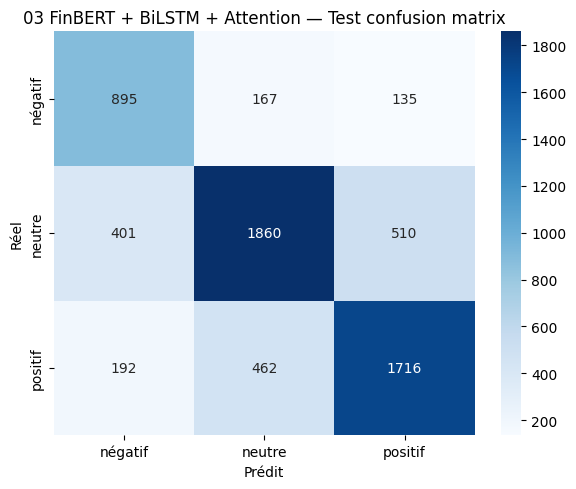

In [22]:
# =======================================================
# 6) Model 03 block — FinBERT + BiLSTM + Attention
# =======================================================
CFG_03 = {
    "model_name": "03_finbert_bilstm_attention",
    "model_dir": MODELS_DIR / "fintwit_bilstm_attention",
    "max_length": 32,
    "batch_size": 16,
    "grad_accum": 1,
    "lstm_hidden": 64,
    "lr_bert": 2e-5,
    "lr_head": 1e-3,
    "weight_decay": 0.01,
    "max_epochs": 4,
    "patience": 1,
    "warmup_ratio": 0.10,
    "freeze_layers": 11,
    "seed": SEED,
}
CFG_03["model_dir"].mkdir(parents=True, exist_ok=True)

tokenizer_03 = get_tokenizer(BACKBONE)
train_loader_03, val_loader_03, test_loader_03 = build_encoded_loaders(
    tokenizer_03, X_train, y_train, X_val, y_val, X_test, y_test,
    max_length=CFG_03["max_length"],
    batch_size=CFG_03["batch_size"]
)

class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x, mask=None):
        scores = self.attn(x).squeeze(-1)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        weights = torch.softmax(scores, dim=1)
        context = torch.sum(x * weights.unsqueeze(-1), dim=1)
        return context, weights


class FinBertBiLSTMAttention(nn.Module):
    def __init__(self, backbone_name, num_classes=3, lstm_hidden=64, freeze_layers=11, tokenizer_len=None):
        super().__init__()
        self.bert = AutoModel.from_pretrained(backbone_name)
        if tokenizer_len is not None:
            self.bert.resize_token_embeddings(tokenizer_len)

        for p in self.bert.embeddings.parameters():
            p.requires_grad = False
        for i, layer in enumerate(self.bert.encoder.layer):
            if i < freeze_layers:
                for p in layer.parameters():
                    p.requires_grad = False

        hidden_size = self.bert.config.hidden_size
        self.bilstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.attention = AttentionLayer(lstm_hidden * 2)
        self.drop1 = nn.Dropout(0.3)
        self.dense = nn.Linear(lstm_hidden * 2, 128)
        self.relu = nn.ReLU()
        self.drop2 = nn.Dropout(0.2)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        seq = outputs.last_hidden_state
        lstm_out, _ = self.bilstm(seq)
        context, _ = self.attention(lstm_out, mask=attention_mask)
        x = self.drop1(context)
        x = self.relu(self.dense(x))
        x = self.drop2(x)
        logits = self.classifier(x)
        return logits


def train_epoch_03(model, loader, optimizer, scheduler, criterion, grad_accum=1, log_every=200):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()
    t0 = time.time()

    for step, batch in enumerate(loader):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels) / grad_accum
        loss.backward()

        total_loss += loss.item() * grad_accum

        if (step + 1) % grad_accum == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        if (step + 1) % log_every == 0:
            elapsed_min = (time.time() - t0) / 60
            avg_loss = total_loss / (step + 1)
            est_total_min = elapsed_min * len(loader) / (step + 1)
            print(
                f"    batch {step+1}/{len(loader)} | "
                f"avg_loss={avg_loss:.4f} | "
                f"elapsed={elapsed_min:.1f} min | "
                f"est_epoch={est_total_min:.1f} min"
            )

    if len(loader) % grad_accum != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    return total_loss / len(loader)


model_03 = FinBertBiLSTMAttention(
    BACKBONE,
    lstm_hidden=CFG_03["lstm_hidden"],
    freeze_layers=CFG_03["freeze_layers"],
    tokenizer_len=len(tokenizer_03)
).to(DEVICE)

trainable_params_03 = sum(p.numel() for p in model_03.parameters() if p.requires_grad)
print("Trainable params (03):", f"{trainable_params_03:,}")

bert_params_03 = [p for p in model_03.bert.parameters() if p.requires_grad]
head_params_03 = [
    p for name, p in model_03.named_parameters()
    if not name.startswith("bert.") and p.requires_grad
]

optimizer_03 = torch.optim.AdamW([
    {"params": bert_params_03, "lr": CFG_03["lr_bert"]},
    {"params": head_params_03, "lr": CFG_03["lr_head"]},
], weight_decay=CFG_03["weight_decay"])

effective_steps_03 = math.ceil(len(train_loader_03) / CFG_03["grad_accum"]) * CFG_03["max_epochs"]
warmup_steps_03 = int(effective_steps_03 * CFG_03["warmup_ratio"])
scheduler_03 = get_linear_schedule_with_warmup(
    optimizer_03,
    num_warmup_steps=warmup_steps_03,
    num_training_steps=effective_steps_03
)
criterion_03 = nn.CrossEntropyLoss(weight=class_weights_tensor.to(DEVICE))

history_03 = {"train_loss": [], "val_loss": [], "val_f1": [], "val_acc": []}
best_val_f1_03 = -1.0
best_epoch_03 = 0
patience_counter_03 = 0

t0 = time.time()
for epoch in range(1, CFG_03["max_epochs"] + 1):
    epoch_t0 = time.time()

    train_loss = train_epoch_03(
        model_03, train_loader_03, optimizer_03, scheduler_03, criterion_03,
        grad_accum=CFG_03["grad_accum"]
    )
    val_metrics_epoch, _, _, _ = evaluate_torch(model_03, val_loader_03, criterion_03)

    history_03["train_loss"].append(train_loss)
    history_03["val_loss"].append(val_metrics_epoch["loss"])
    history_03["val_f1"].append(val_metrics_epoch["f1_macro"])
    history_03["val_acc"].append(val_metrics_epoch["accuracy"])

    print(
        f"[03] Epoch {epoch:02d}/{CFG_03['max_epochs']} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics_epoch['loss']:.4f} | "
        f"val_acc={val_metrics_epoch['accuracy']:.4f} | "
        f"val_f1={val_metrics_epoch['f1_macro']:.4f} | "
        f"time={(time.time()-epoch_t0)/60:.1f} min"
    )

    if val_metrics_epoch["f1_macro"] > best_val_f1_03:
        best_val_f1_03 = val_metrics_epoch["f1_macro"]
        best_epoch_03 = epoch
        patience_counter_03 = 0
        torch.save(model_03.state_dict(), CFG_03["model_dir"] / "best_model.pt")
    else:
        patience_counter_03 += 1
        if patience_counter_03 >= CFG_03["patience"]:
            print(f"[03] Early stopping at epoch {epoch}")
            break

training_minutes_03 = (time.time() - t0) / 60

model_03.load_state_dict(torch.load(CFG_03["model_dir"] / "best_model.pt", map_location=DEVICE))
val_metrics_03, val_preds_03, val_labels_03, val_probs_03 = evaluate_torch(model_03, val_loader_03, criterion_03)
test_metrics_03, test_preds_03, test_labels_03, test_probs_03 = evaluate_torch(model_03, test_loader_03, criterion_03)

np.save(RES_DIR / "03_test_preds.npy", np.array(test_preds_03))
np.save(RES_DIR / "03_test_labels.npy", np.array(test_labels_03))

metrics_03 = save_unified_metrics(
    out_json_path=RES_DIR / "metrics_03.json",
    model_name=CFG_03["model_name"],
    val_metrics=val_metrics_03,
    test_metrics=test_metrics_03,
    training_time_minutes=training_minutes_03,
    best_epoch=best_epoch_03,
    trainable_params=trainable_params_03,
    val_f1_history=history_03["val_f1"],
    config=CFG_03
)

print(json.dumps(metrics_03, indent=2, ensure_ascii=False))
print(classification_report(test_labels_03, test_preds_03, target_names=LABEL_NAMES))
plot_confusion(test_labels_03, test_preds_03, "03 FinBERT + BiLSTM + Attention — Test confusion matrix", RES_DIR / "confusion_03_test.png")

free_memory(model_03, optimizer_03, scheduler_03, train_loader_03, val_loader_03, test_loader_03)

## 04) Unified comparison block

This block reads only the saved JSON metrics and saved prediction arrays.  
It does **not** reload deep checkpoints.

,model,val_f1_macro,test_f1_macro,test_accuracy,test_roc_auc,training_time_minutes,best_epoch,trainable_params
0,02_finbert_bilstm,0.7103,0.7139,0.7198,0.8796,159.6,4,8368643
1,03_finbert_bilstm_attention,0.6980,0.6998,0.7054,0.8673,127.0,4,8122500
2,01_finbert_classifier,0.6837,0.6848,0.6904,0.8607,151.5,3,14963971
3,baseline_tfidf_logreg,0.6731,0.6752,0.6939,0.8557,0.1,1,29685


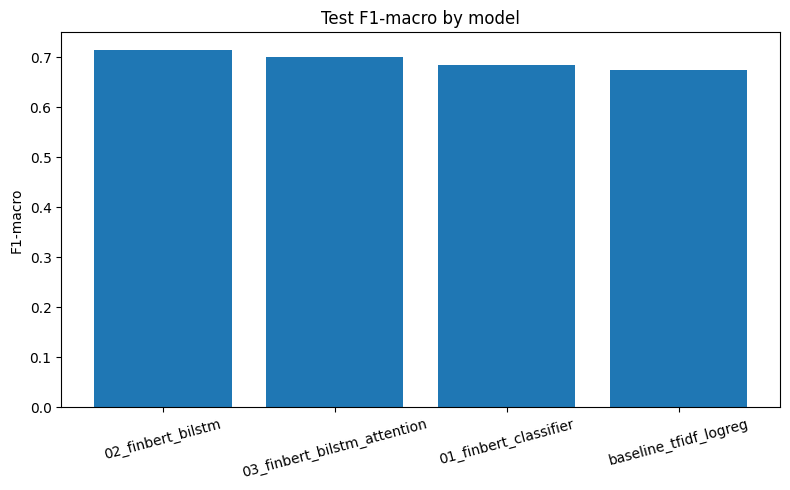

In [33]:
# ============================================
# 7) Unified comparison block
# ============================================
with open(RES_DIR / "metrics_baseline.json", encoding="utf-8") as f:
    m_base = json.load(f)
with open(RES_DIR / "metrics_01.json", encoding="utf-8") as f:
    m_01 = json.load(f)
with open(RES_DIR / "metrics_02.json", encoding="utf-8") as f:
    m_02 = json.load(f)
with open(RES_DIR / "metrics_03.json", encoding="utf-8") as f:
    m_03 = json.load(f)

metrics_map = {
    "baseline": m_base,
    "01": m_01,
    "02": m_02,
    "03": m_03,
}

rows = []
for key, m in metrics_map.items():
    rows.append({
        "model": m["model"],
        "val_f1_macro": m["val"]["f1_macro"],
        "test_f1_macro": m["test"]["f1_macro"],
        "test_accuracy": m["test"]["accuracy"],
        "test_roc_auc": m["test"]["roc_auc"],
        "training_time_minutes": m["training_time_minutes"],
        "best_epoch": m["best_epoch"],
        "trainable_params": m["trainable_params"],
    })

df_compare = pd.DataFrame(rows).sort_values("test_f1_macro", ascending=False).reset_index(drop=True)
display(df_compare)

plt.figure(figsize=(8, 5))
plt.bar(df_compare["model"], df_compare["test_f1_macro"])
plt.title("Test F1-macro by model")
plt.ylabel("F1-macro")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(RES_DIR / "comparison_test_f1.png", dpi=140, bbox_inches="tight")
plt.show()

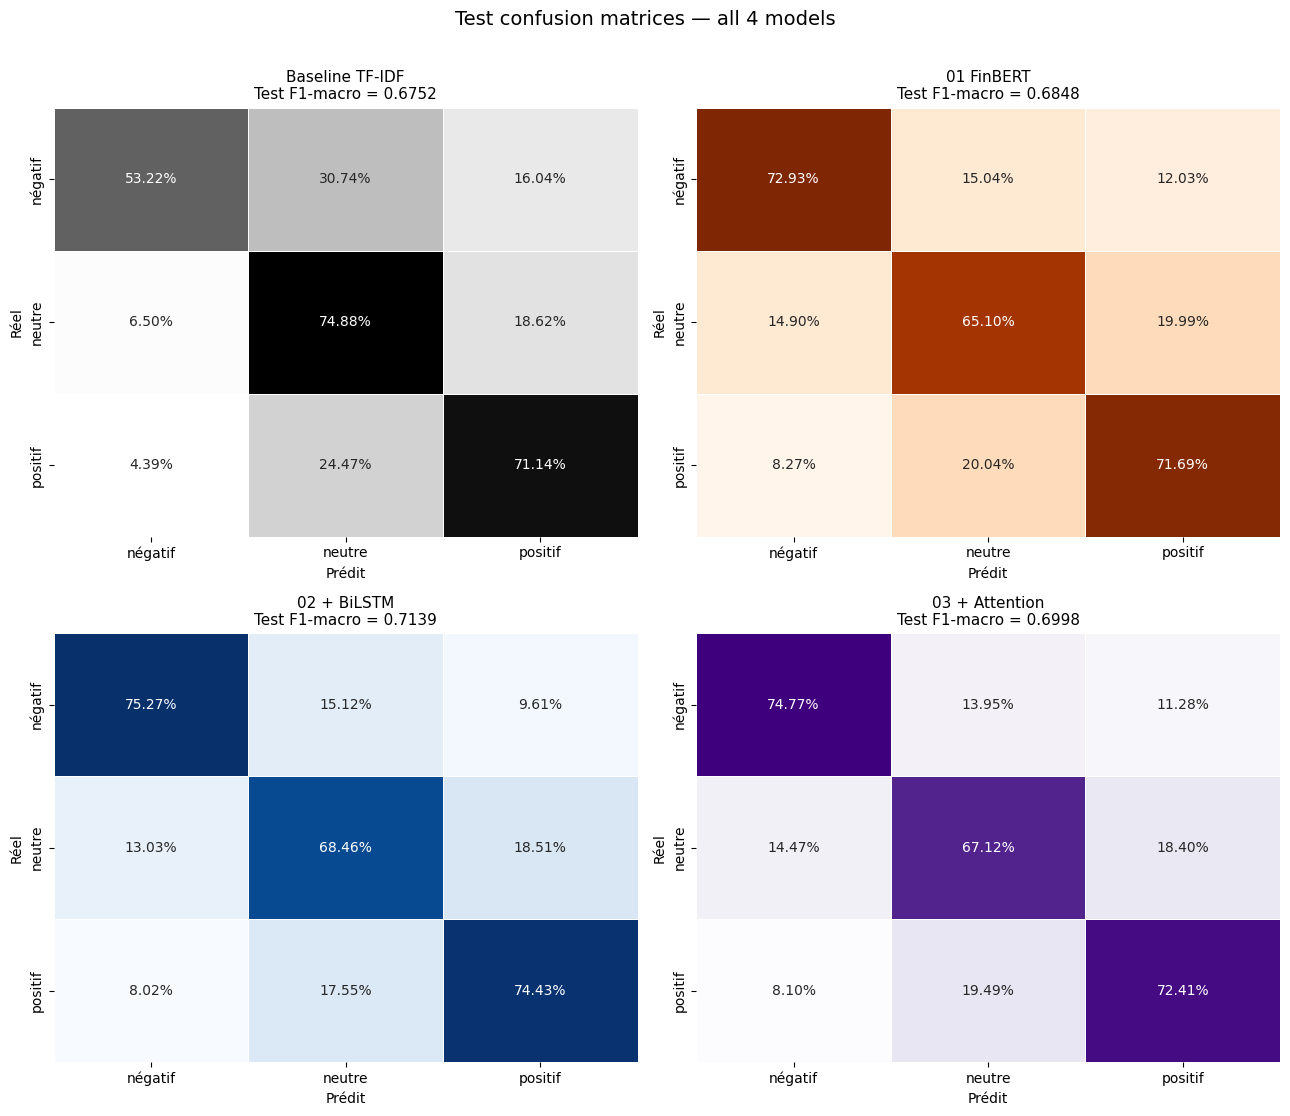

In [34]:
# ============================================
# 8) 4 confusion matrices side by side
# ============================================
true_labels = np.load(RES_DIR / "baseline_test_labels.npy").tolist()

all_preds = {
    "baseline": np.load(RES_DIR / "baseline_test_preds.npy").tolist(),
    "01": np.load(RES_DIR / "01_test_preds.npy").tolist(),
    "02": np.load(RES_DIR / "02_test_preds.npy").tolist(),
    "03": np.load(RES_DIR / "03_test_preds.npy").tolist(),
}

plot_items = [
    ("baseline", "Baseline TF-IDF", "Greys"),
    ("01", "01 FinBERT", "Oranges"),
    ("02", "02 + BiLSTM", "Blues"),
    ("03", "03 + Attention", "Purples"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, (key, title, cmap) in zip(axes, plot_items):
    preds = all_preds[key]
    cm = confusion_matrix(true_labels, preds, normalize="true")
    sns.heatmap(
        cm, ax=ax, annot=True, fmt=".2%", cmap=cmap,
        xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
        linewidths=0.5, cbar=False
    )
    f1 = metrics_map[key]["test"]["f1_macro"]
    ax.set_title(f"{title}\nTest F1-macro = {f1:.4f}", fontsize=11)
    ax.set_ylabel("Réel")
    ax.set_xlabel("Prédit")

plt.suptitle("Test confusion matrices — all 4 models", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(RES_DIR / "confusion_matrices_4models.png", dpi=140, bbox_inches="tight")
plt.show()

## Final note

If runtime is still too high on your laptop, reduce in this order:

1. `MAX_LENGTH`
2. `MAX_EPOCHS`
3. `FREEZE_LAYERS`
4. `lstm_hidden`
5. run only model 01 first, then 02, then 03

,display_name,val_f1_macro,test_f1_macro,test_accuracy,test_roc_auc,training_time_minutes,best_epoch,trainable_params
0,02 FinBERT + BiLSTM,0.7103,0.7139,0.7198,0.8796,159.6,4,"8,368,643"
1,03 FinBERT + BiLSTM + Attention,0.6980,0.6998,0.7054,0.8673,127.0,4,"8,122,500"
2,01 FinBERT,0.6837,0.6848,0.6904,0.8607,151.5,3,"14,963,971"
3,Baseline TF-IDF + LogReg,0.6731,0.6752,0.6939,0.8557,0.1,1,"29,685"


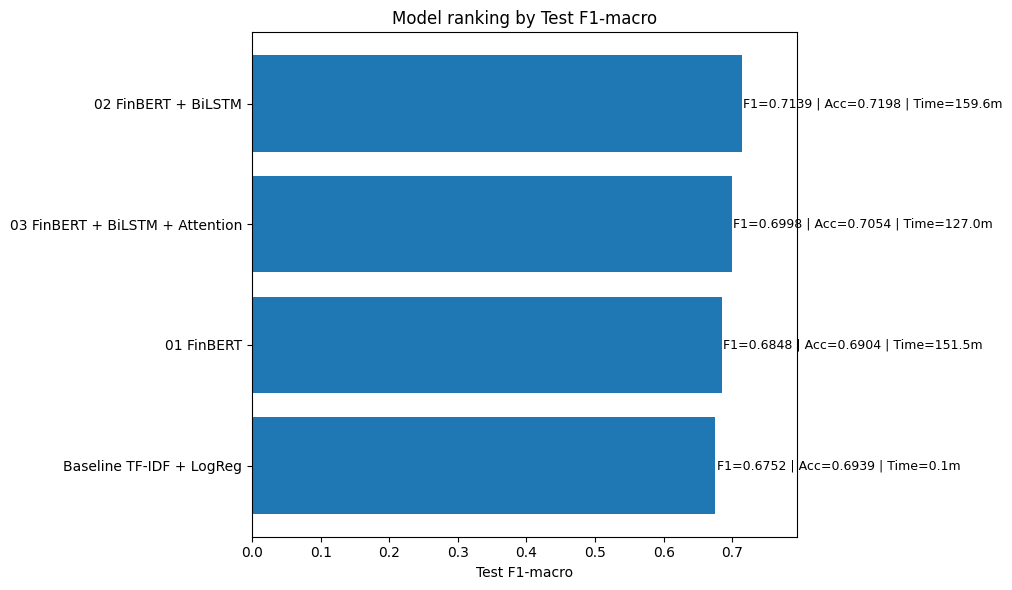

In [35]:
# ============================================
# 9) Executive leaderboard table + annotated ranking
# ============================================
display_names = {
    "baseline_tfidf_logreg": "Baseline TF-IDF + LogReg",
    "01_finbert_classifier": "01 FinBERT",
    "02_finbert_bilstm": "02 FinBERT + BiLSTM",
    "03_finbert_bilstm_attention": "03 FinBERT + BiLSTM + Attention",
}

df_exec = df_compare.copy()
df_exec["display_name"] = df_exec["model"].map(display_names).fillna(df_exec["model"])
df_exec["training_time_minutes"] = df_exec["training_time_minutes"].fillna(0)
df_exec["trainable_params"] = df_exec["trainable_params"].fillna(0)

display(
    df_exec[[
        "display_name",
        "val_f1_macro",
        "test_f1_macro",
        "test_accuracy",
        "test_roc_auc",
        "training_time_minutes",
        "best_epoch",
        "trainable_params"
    ]].sort_values("test_f1_macro", ascending=False).style
      .format({
          "val_f1_macro": "{:.4f}",
          "test_f1_macro": "{:.4f}",
          "test_accuracy": "{:.4f}",
          "test_roc_auc": "{:.4f}",
          "training_time_minutes": "{:.1f}",
          "trainable_params": "{:,.0f}"
      })
      .background_gradient(subset=["test_f1_macro", "test_accuracy", "test_roc_auc"], cmap="Greens")
      .background_gradient(subset=["training_time_minutes", "trainable_params"], cmap="Reds_r")
)

ranked = df_exec.sort_values("test_f1_macro", ascending=True).reset_index(drop=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(ranked["display_name"], ranked["test_f1_macro"])
plt.xlabel("Test F1-macro")
plt.title("Model ranking by Test F1-macro")

for i, (_, row) in enumerate(ranked.iterrows()):
    plt.text(
        row["test_f1_macro"] + 0.002,
        i,
        f'F1={row["test_f1_macro"]:.4f} | Acc={row["test_accuracy"]:.4f} | Time={row["training_time_minutes"]:.1f}m',
        va="center",
        fontsize=9
    )

plt.xlim(0, max(ranked["test_f1_macro"]) + 0.08)
plt.tight_layout()
plt.savefig(RES_DIR / "executive_leaderboard.png", dpi=160, bbox_inches="tight")
plt.show()

In [36]:
# ============================================
# 18) List all generated result figures
# ============================================
generated_pngs = sorted([p.name for p in RES_DIR.glob("*.png")])
print("Generated figures:")
for p in generated_pngs:
    print(" -", p)

Generated figures:
 - baseline_top_features.png
 - class_distribution.png
 - comparison_test_f1.png
 - confusion_01_test.png
 - confusion_02_test.png
 - confusion_03_test.png
 - confusion_baseline_test.png
 - confusion_baseline_val.png
 - confusion_matrices_4models.png
 - executive_leaderboard.png
